In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [225]:
train = pd.read_csv("Titanic_train.csv")
test = pd.read_csv("Titanic_test.csv")

In [226]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [227]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


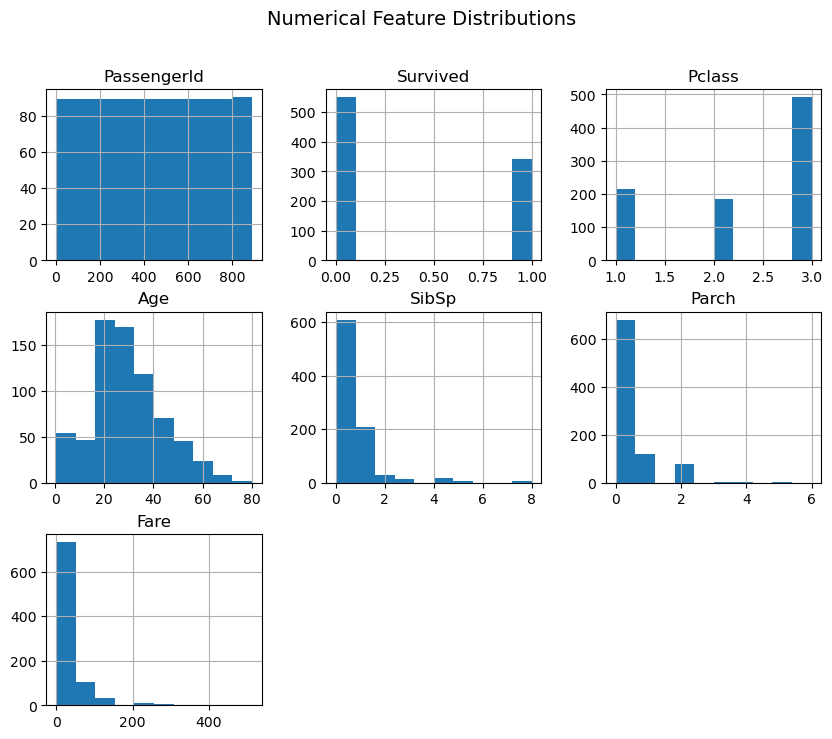

In [228]:
train.hist(figsize=(10, 8))
plt.suptitle("Numerical Feature Distributions", fontsize=14)
plt.show()

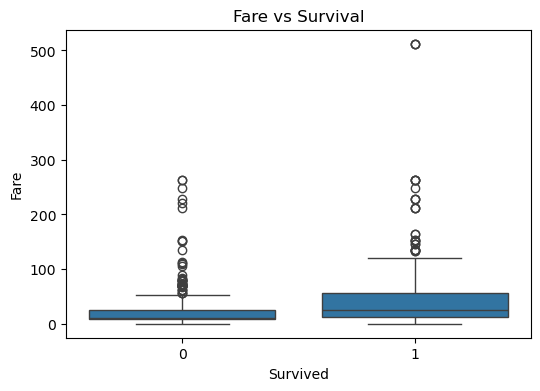

In [229]:
# Boxplot: Fare vs Survived
plt.figure(figsize=(6, 4))
sns.boxplot(x="Survived", y="Fare", data=train)
plt.title("Fare vs Survival")
plt.show()

In [230]:
train.shape

(891, 12)

In [231]:
test.shape

(418, 11)

In [232]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [233]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [234]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [235]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [236]:
train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [237]:
test_passenger_ids = test["PassengerId"]

In [238]:
# Impute missing values
train["Age"].fillna(train["Age"].median(), inplace=True)
train["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)
train["Cabin"].fillna(train["Cabin"].mode()[0], inplace=True)
test["Age"].fillna(test["Age"].median(), inplace=True)
test["Fare"].fillna(test["Fare"].median(), inplace=True)
test["Cabin"].fillna(test["Cabin"].mode()[0], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_26928\1758399964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Age"].fillna(train["Age"].median(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_26928\1758399964.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [239]:
train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [240]:
test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [241]:
# Drop columns not useful for prediction
train = train.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)
test_passenger_ids = test["PassengerId"]
test = test.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [242]:
le = LabelEncoder()
for col in ['Sex','Embarked']:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [243]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [244]:
def evaluate_cif(y,yhat):
    cm=confusion_matrix(y,yhat)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,cbar=False,annot=True,fmt='d')
    plt.show()
    print(classification_report(y_train,yhat_train))
    plt.figure(figsize=(3,3))
    plt.title('AUC_ROC Curve')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    fpr,tpr,thresh=roc_curve(y,yhat)
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],linestyle='dashed')
    plt.show()
    print(roc_auc_score(y_train,yhat_train))

In [245]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [246]:
clf=XGBClassifier(max_depth=4)
clf.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

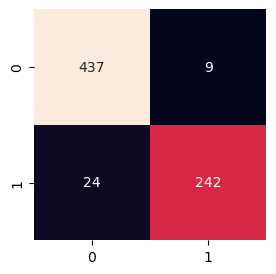

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       446
           1       0.96      0.91      0.94       266

    accuracy                           0.95       712
   macro avg       0.96      0.94      0.95       712
weighted avg       0.95      0.95      0.95       712



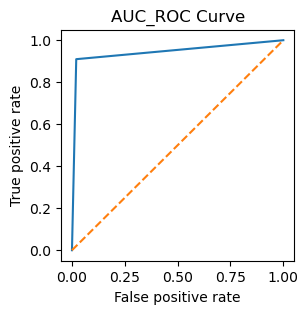

0.9447975319464581


In [247]:
yhat_train=clf.predict(x_train)
evaluate_cif(y_train,yhat_train)

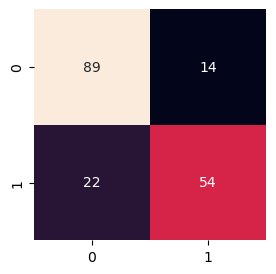

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       446
           1       0.96      0.91      0.94       266

    accuracy                           0.95       712
   macro avg       0.96      0.94      0.95       712
weighted avg       0.95      0.95      0.95       712



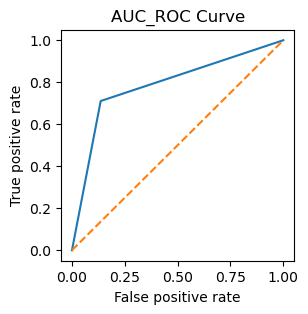

0.9447975319464581


In [248]:
yhat_test=clf.predict(x_test)
evaluate_cif(y_test,yhat_test)

In [249]:
rtest=clf.predict(test)
submission1= pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": rtest
})

In [250]:
submission1

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [251]:
light_model=LGBMClassifier()
light_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 266, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373596 -> initscore=-0.516823
[LightGBM] [Info] Start training from score -0.516823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

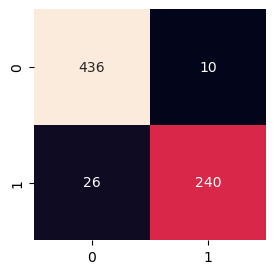

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       446
           1       0.96      0.90      0.93       266

    accuracy                           0.95       712
   macro avg       0.95      0.94      0.95       712
weighted avg       0.95      0.95      0.95       712



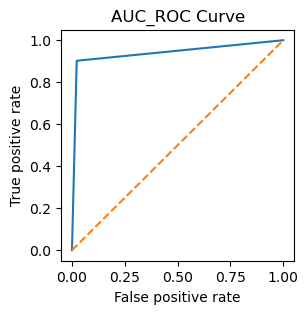

0.9399170572170337


In [252]:
yhat_train=light_model.predict(x_train)
evaluate_cif(y_train,yhat_train)

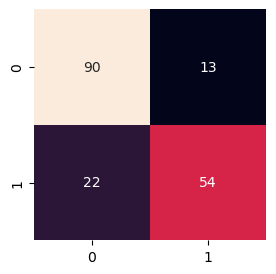

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       446
           1       0.96      0.90      0.93       266

    accuracy                           0.95       712
   macro avg       0.95      0.94      0.95       712
weighted avg       0.95      0.95      0.95       712



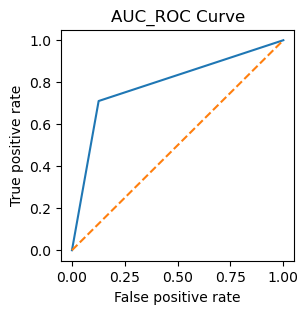

0.9399170572170337


In [253]:
yhat_test=light_model.predict(x_test)
evaluate_cif(y_test,yhat_test)

In [254]:
test=light_model.predict(test)
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test
})

In [255]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
